# Deep SRQ PATH MCP N-player Pool Training

Training-only notebook for Deep SRQ with the `path_mcp_nplayer_pool` stage-game solver using 8 worker processes. Each epsilon cell runs all configured LBF scenarios and saves full-resume checkpoints plus reward plots.

In [1]:
from pathlib import Path
import sys

ROOT = Path.cwd()
if ROOT.name == "lbf_grid":
    REPO_ROOT = ROOT.parents[1]
elif (ROOT / "discrete_action_space" / "lbf_grid").exists():
    REPO_ROOT = ROOT
else:
    REPO_ROOT = ROOT.parents[1]

for path in [REPO_ROOT, REPO_ROOT / "discrete_action_space", REPO_ROOT / "discrete_action_space" / "lbf_grid"]:
    if str(path) not in sys.path:
        sys.path.insert(0, str(path))

from discrete_action_space.lbf_grid.robust_notebook_utils import (
    DEFAULT_EVAL_EPISODES,
    ROBUST_EPSILONS,
    evaluate_deepsrq_path_mcp_pool_suite_for_epsilon,
    robust_lbf_scenarios,
    train_deepsrq_path_mcp_pool_for_epsilon,
)
from discrete_action_space.lbf_grid.notebook_eval import display_training_reward_plots

# SCENARIOS = robust_lbf_scenarios()
# for scenario in SCENARIOS:
#     print(f"{scenario.key}: {scenario.name}")
SCENARIOS = robust_lbf_scenarios()[:2]

def newly_trained_records(records):
    return [record for record in records if record.get("status") != "skipped_existing"]


In [2]:
N_EPISODES = 3000
USE_GPU = True
BASE_SEED = 2025
EVAL_INTERVAL = 100
EVAL_EPISODES_DURING_TRAINING = 30
NUM_ENVS = 32
EVAL_NUM_ENVS = 8
SRE_SOLVER_WORKERS = 16
SKIP_EXISTING_TRAINING = True
USE_ACTION_MASKS = False
PATH_POOL_NPLAYER_SOLVER = "path_c_pool"
PATH_MCP_HYPERPARAMETER_OVERRIDES = {
    "agent": {
        "sre_num_random_starts": 5,
        "sre_num_pure_starts": 10,
        "train_every": 4,
        "target_equilibrium_update_steps": 1,
        "sre_policy_cache_enabled": False,
    },
}


## Robust epsilon 0.01

LBF DeepSRQ vectorized | players=2 | solver=path_c_pool | eps0=0.01 | schedule=constant | seed=2026 | num_envs=32 | action_masks=False | agent_device=cuda | solver_device=n/a


lbf:path_c_pool_eps0.01_constant:vec:   4%|█▌                                      | 116/3000 [05:07<1:44:22,  2.17s/it]

[ep   100] train_joint=  3.0400 | eval_joint=  1.2000 | best_loss=0.007286 | latest_loss=0.029992 | solver_mean_ms=44.761


lbf:path_c_pool_eps0.01_constant:vec:   7%|██▉                                     | 216/3000 [08:12<1:07:29,  1.45s/it]

[ep   200] train_joint=  2.8000 | eval_joint=  0.8000 | best_loss=0.006872 | latest_loss=0.050064 | solver_mean_ms=42.268


...

[ep  2900] train_joint=  1.9400 | eval_joint=  0.9000 | best_loss=0.003279 | latest_loss=0.007758 | solver_mean_ms=44.368


lbf:path_c_pool_eps0.01_constant:vec:  99%|██████████████████████████████████████▋| 2977/3000 [2:14:00<01:25,  3.72s/it]

[ep  3000] train_joint=  1.8700 | eval_joint=  0.9667 | best_loss=0.003279 | latest_loss=0.009340 | solver_mean_ms=44.459


lbf:path_c_pool_eps0.01_constant:vec: 100%|███████████████████████████████████████| 3000/3000 [2:14:14<00:00,  2.68s/it]



Reward Summary
Scenario                                                                                                      | Pair              | Agent             | Mean | Std  | Mean (Last 1000) | Std (Last 1000) | Episodes
--------------------------------------------------------------------------------------------------------------+-------------------+-------------------+------+------+------------------+-----------------+---------
2 level-1 agents, 8x8 grid, 10 foods (5 level-1, 5 level-2), full sight, forced cooperation, 50-step episodes | DeepSRQ self-play | Agent 1 (DeepSRQ) | 1.20 | 0.98 | 1.06             | 0.94            | 3000    
2 level-1 agents, 8x8 grid, 10 foods (5 level-1, 5 level-2), full sight, forced cooperation, 50-step episodes | DeepSRQ self-play | Agent 2 (DeepSRQ) | 1.16 | 0.95 | 1.13             | 0.96            | 3000    
DeepSRQ PATH pool lbf_8x8_2p_2f_force_coop solver=path_c_pool eps=0.01 ep=3000 best_loss=0.0032786764204502106 latest_loss=0.00934006180

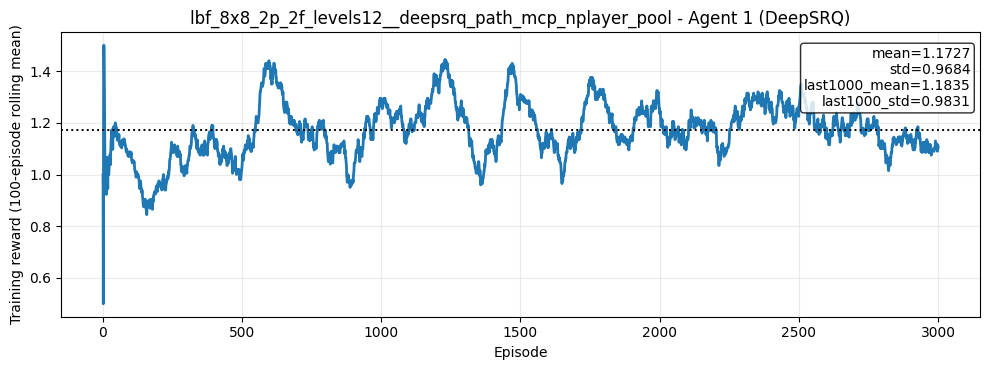

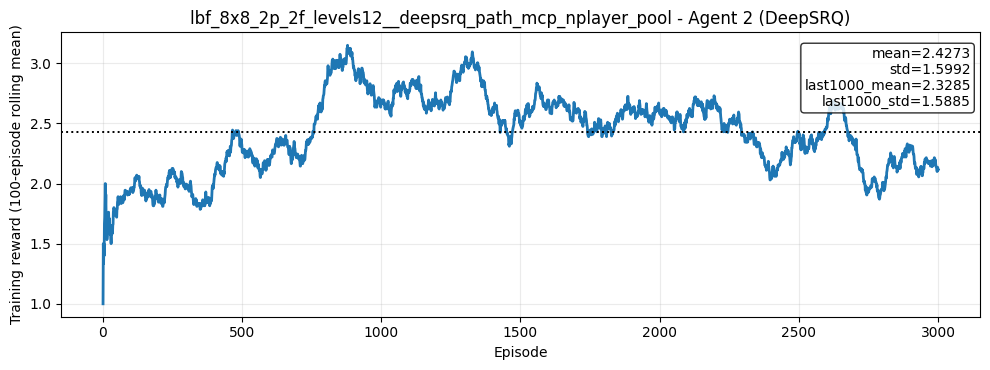

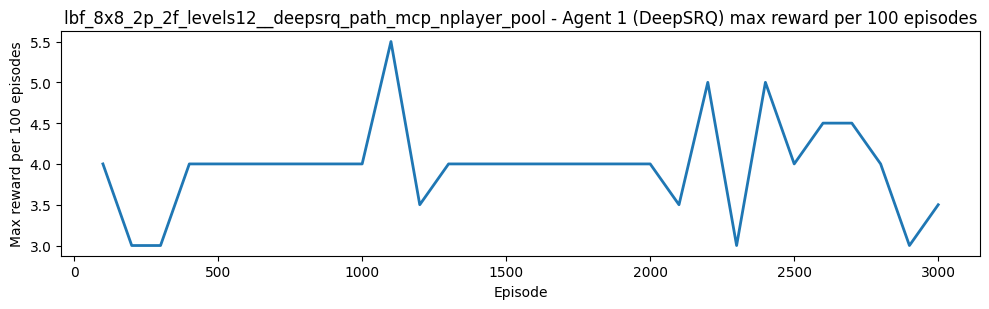

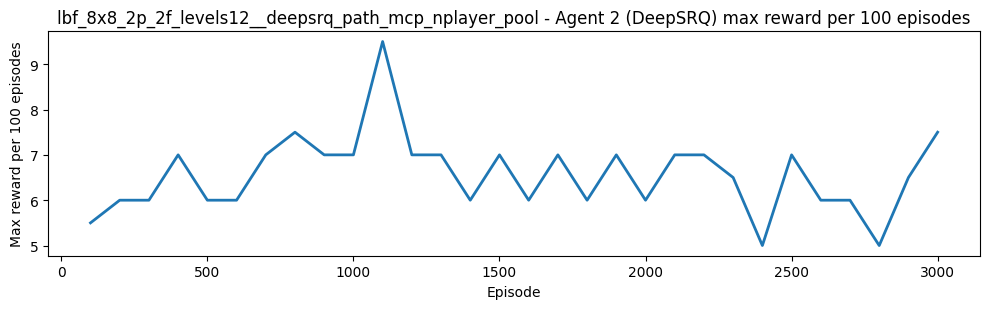

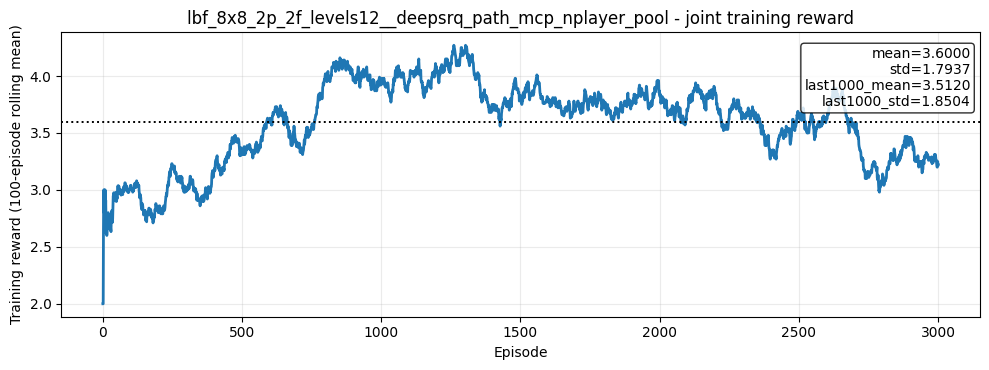

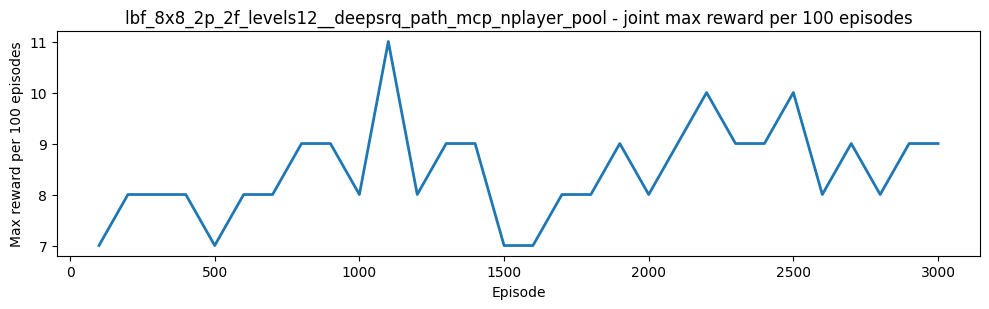

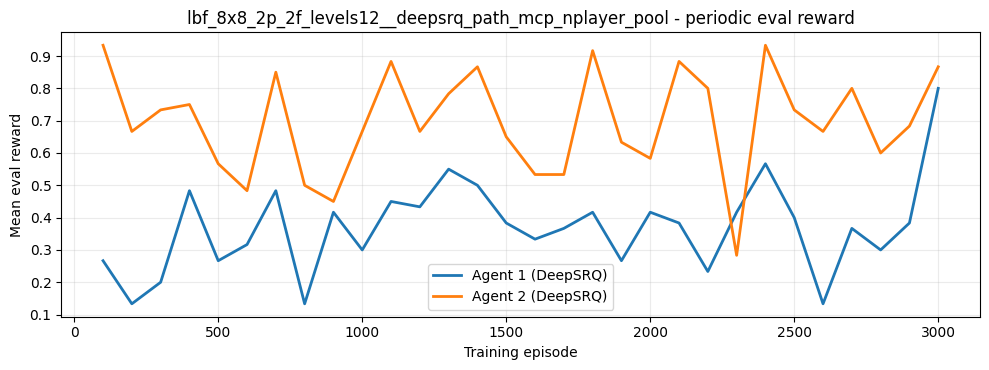

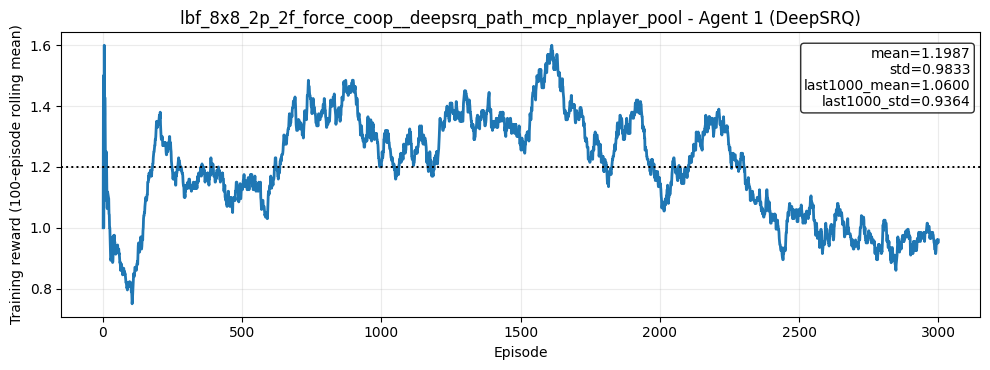

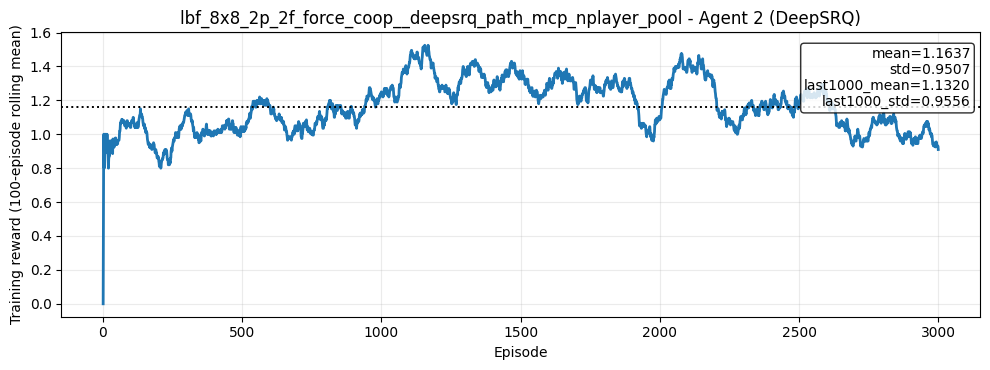

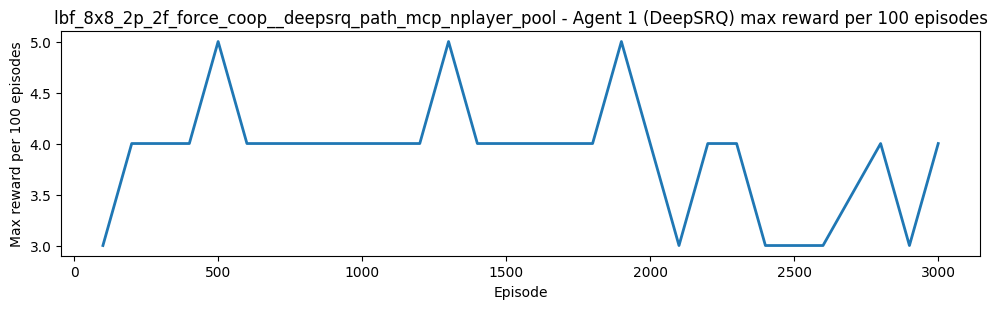

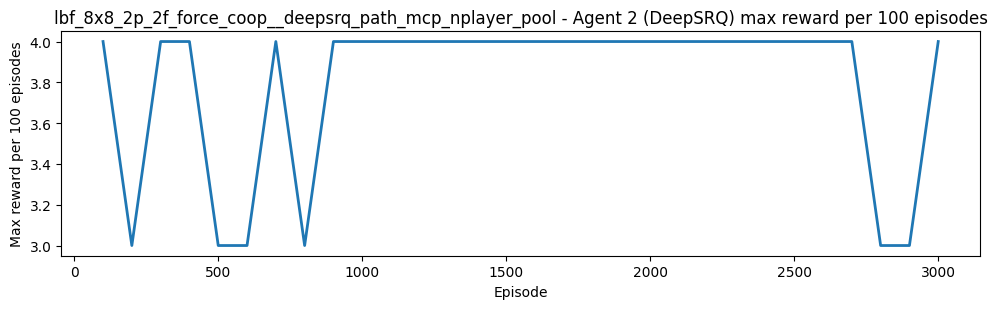

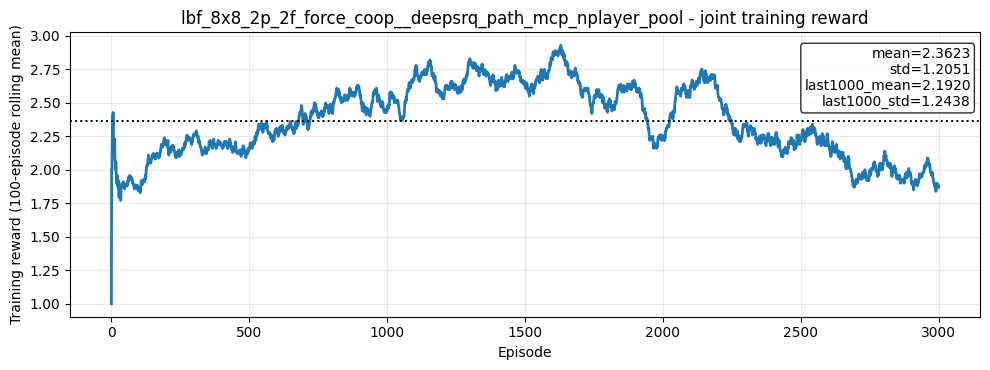

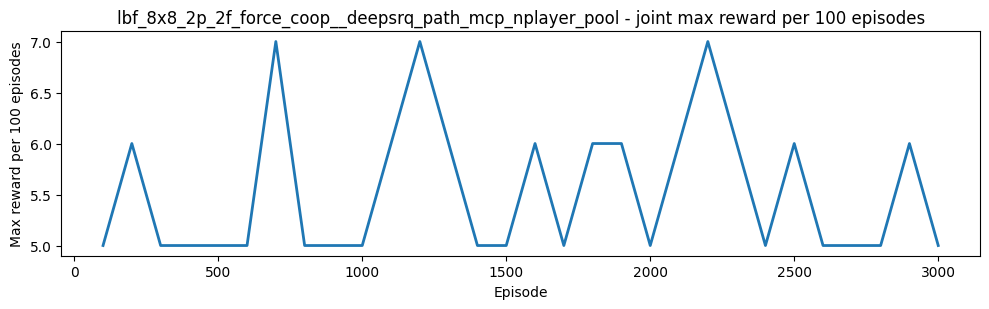

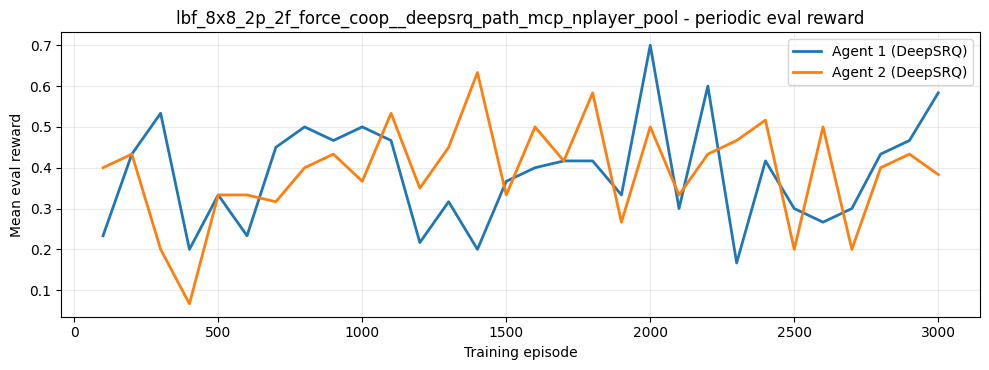

In [3]:
deep_srq_path_pool_eps_0_01_stats = train_deepsrq_path_mcp_pool_for_epsilon(
    0.01,
    n_episodes=N_EPISODES,
    scenarios=SCENARIOS,
    base_seed=BASE_SEED + 1,
    use_gpu=USE_GPU,
    eval_interval=EVAL_INTERVAL,
    eval_episodes=EVAL_EPISODES_DURING_TRAINING,
    sre_solver_workers=SRE_SOLVER_WORKERS,
    num_envs=NUM_ENVS,
    eval_num_envs=EVAL_NUM_ENVS,
    nplayer_solver_name=PATH_POOL_NPLAYER_SOLVER,
    hyperparameter_overrides=PATH_MCP_HYPERPARAMETER_OVERRIDES,
    repo_root=REPO_ROOT,
    skip_existing=SKIP_EXISTING_TRAINING,
    use_action_masks=USE_ACTION_MASKS,
)
deep_srq_path_pool_eps_0_01_training_figs = display_training_reward_plots(newly_trained_records(deep_srq_path_pool_eps_0_01_stats.values()))


## Robust epsilon 0.1

LBF DeepSRQ vectorized | players=2 | solver=path_c_pool | eps0=0.1 | schedule=constant | seed=2035 | num_envs=32 | action_masks=False | agent_device=cuda | solver_device=n/a


lbf:path_c_pool_eps0.1_constant:vec:   4%|█▌                                       | 114/3000 [04:25<1:38:31,  2.05s/it]

[ep   100] train_joint=  3.0200 | eval_joint=  0.8333 | best_loss=0.006782 | latest_loss=0.024038 | solver_mean_ms=41.780


lbf:path_c_pool_eps0.1_constant:vec:   7%|██▊                                      | 204/3000 [08:06<1:56:50,  2.51s/it]

[ep   200] train_joint=  3.2600 | eval_joint=  0.8667 | best_loss=0.006782 | latest_loss=0.098836 | solver_mean_ms=42.055


...

[ep  2900] train_joint=  1.9500 | eval_joint=  0.5333 | best_loss=0.003326 | latest_loss=0.010547 | solver_mean_ms=46.194


lbf:path_c_pool_eps0.1_constant:vec:  99%|███████████████████████████████████████▋| 2977/3000 [2:17:32<01:24,  3.66s/it]

[ep  3000] train_joint=  1.8000 | eval_joint=  1.0667 | best_loss=0.003326 | latest_loss=0.126812 | solver_mean_ms=46.274


lbf:path_c_pool_eps0.1_constant:vec: 100%|████████████████████████████████████████| 3000/3000 [2:17:58<00:00,  2.76s/it]



Reward Summary
Scenario                                                                                                      | Pair              | Agent             | Mean | Std  | Mean (Last 1000) | Std (Last 1000) | Episodes
--------------------------------------------------------------------------------------------------------------+-------------------+-------------------+------+------+------------------+-----------------+---------
2 level-1 agents, 8x8 grid, 10 foods (5 level-1, 5 level-2), full sight, forced cooperation, 50-step episodes | DeepSRQ self-play | Agent 1 (DeepSRQ) | 1.11 | 0.94 | 1.01             | 0.92            | 3000    
2 level-1 agents, 8x8 grid, 10 foods (5 level-1, 5 level-2), full sight, forced cooperation, 50-step episodes | DeepSRQ self-play | Agent 2 (DeepSRQ) | 1.18 | 0.97 | 1.13             | 0.97            | 3000    
DeepSRQ PATH pool lbf_8x8_2p_2f_force_coop solver=path_c_pool eps=0.1 ep=3000 best_loss=0.003325846279039979 latest_loss=0.1268118768930

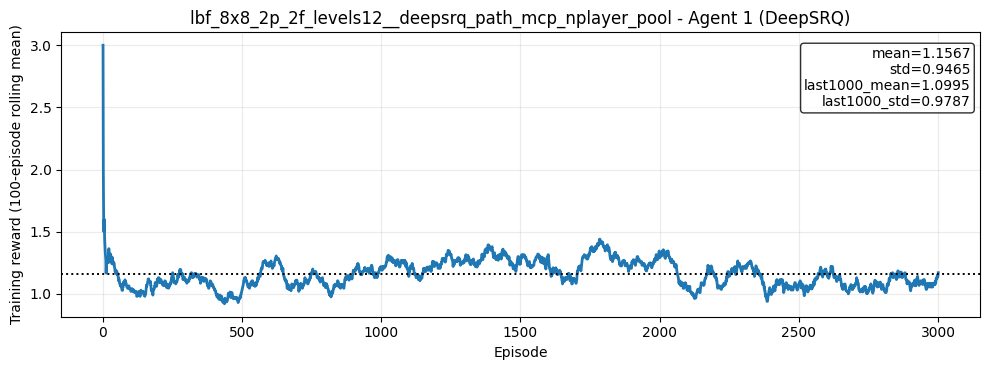

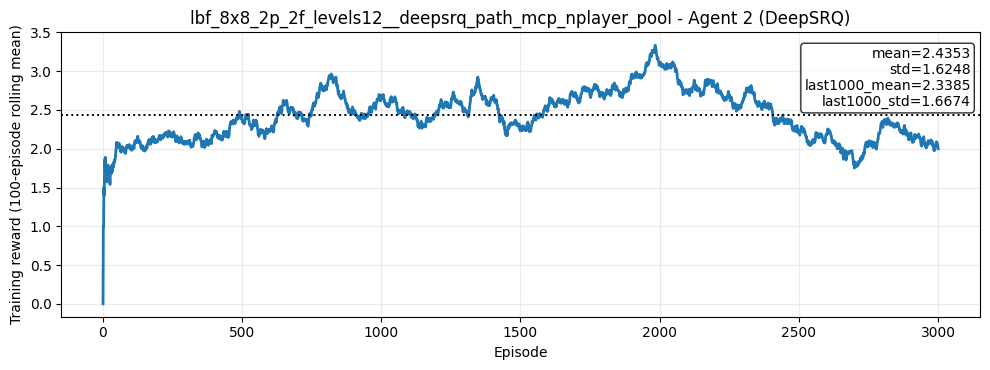

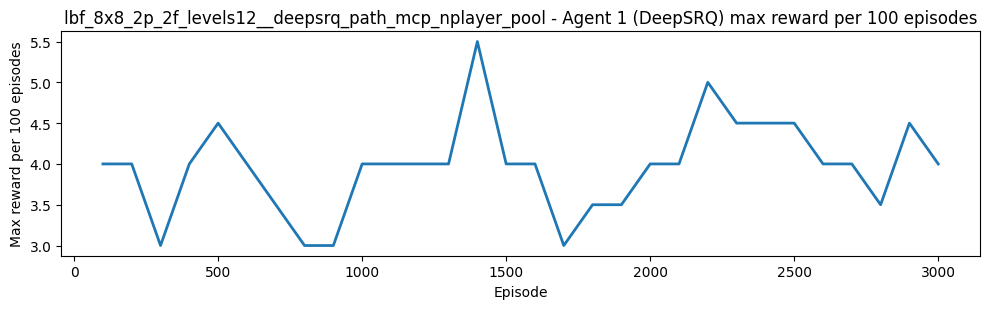

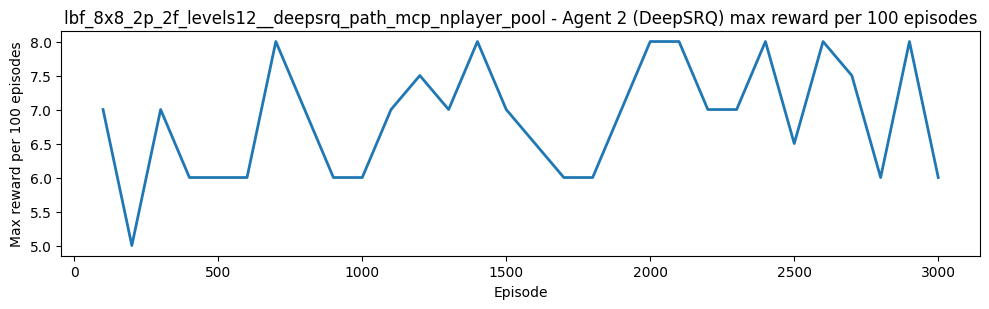

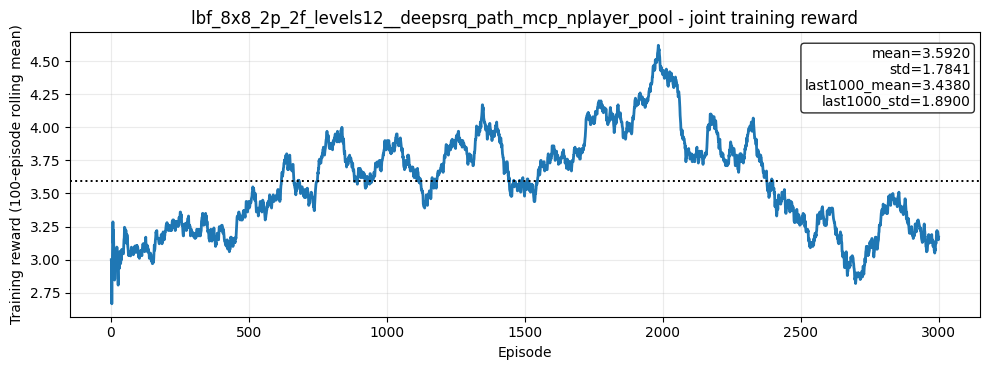

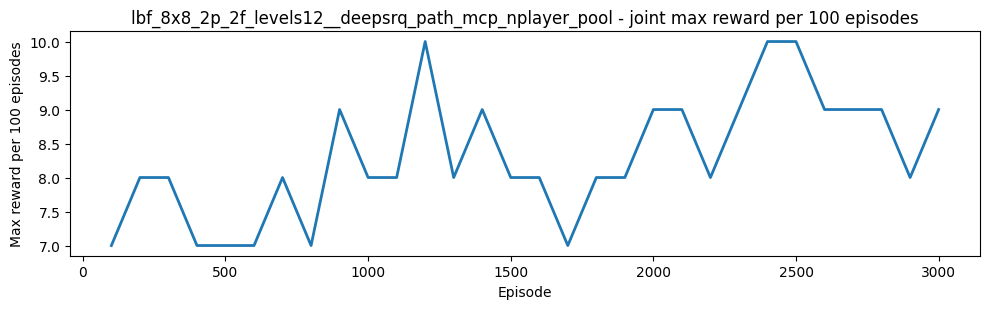

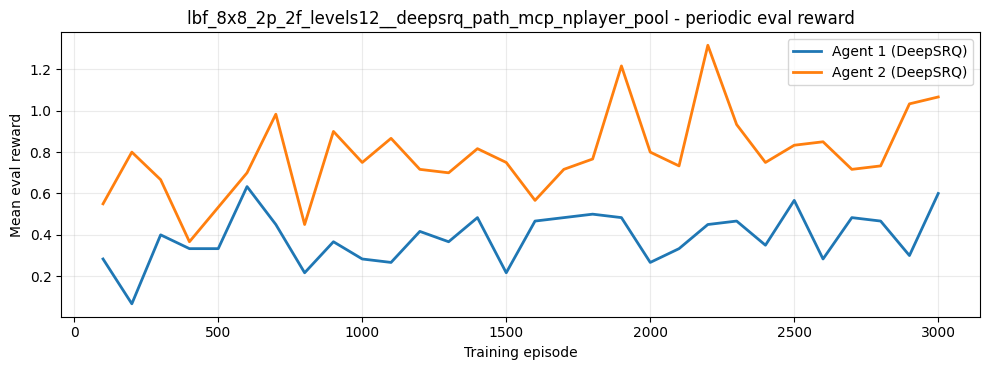

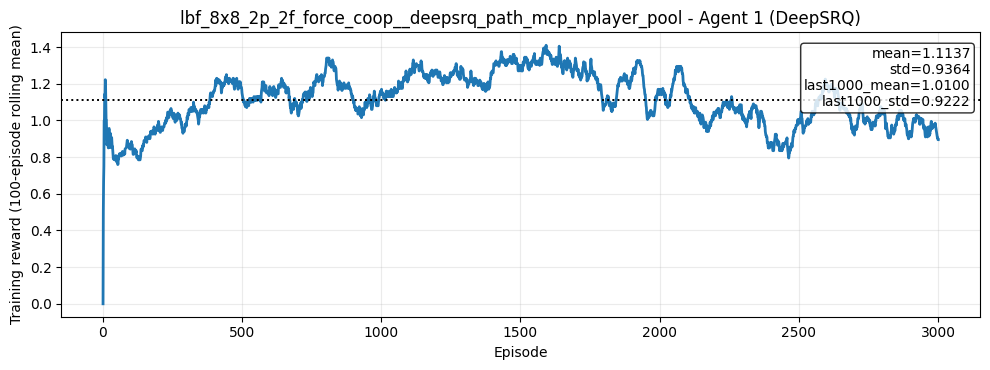

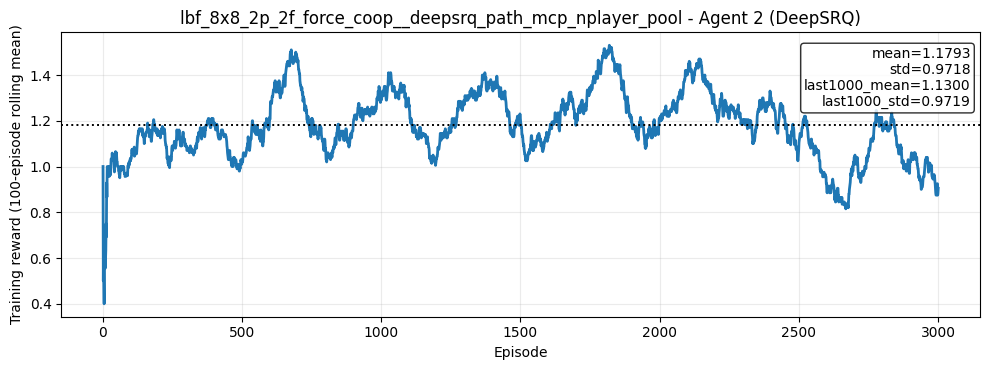

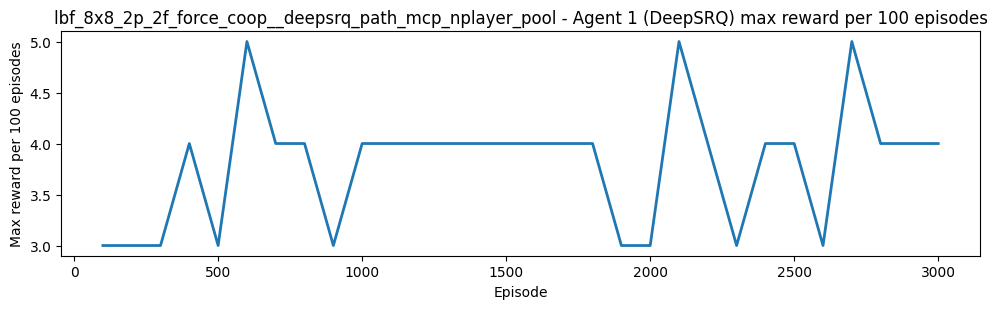

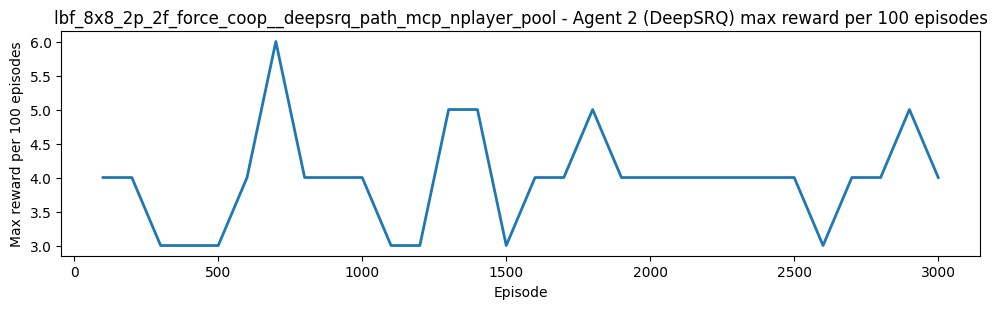

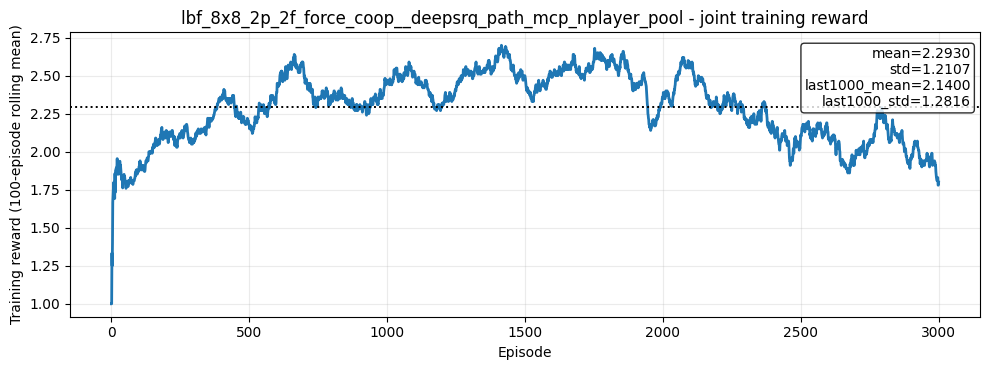

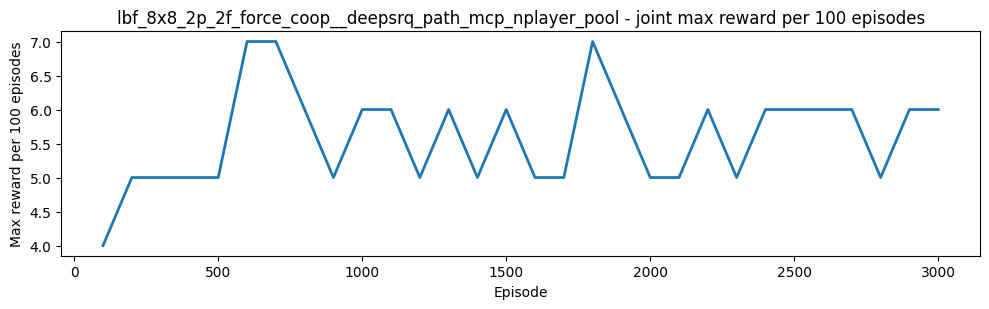

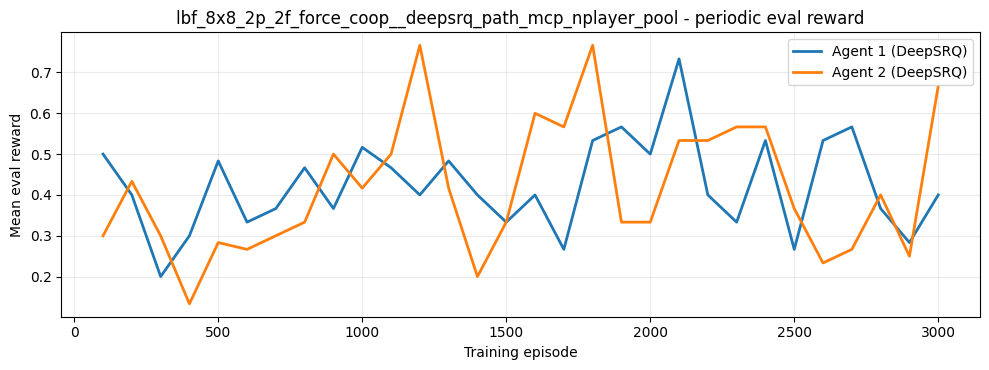

In [4]:
deep_srq_path_pool_eps_0_1_stats = train_deepsrq_path_mcp_pool_for_epsilon(
    0.1,
    n_episodes=N_EPISODES,
    scenarios=SCENARIOS,
    base_seed=BASE_SEED + 10,
    use_gpu=USE_GPU,
    eval_interval=EVAL_INTERVAL,
    eval_episodes=EVAL_EPISODES_DURING_TRAINING,
    sre_solver_workers=SRE_SOLVER_WORKERS,
    num_envs=NUM_ENVS,
    eval_num_envs=EVAL_NUM_ENVS,
    nplayer_solver_name=PATH_POOL_NPLAYER_SOLVER,
    hyperparameter_overrides=PATH_MCP_HYPERPARAMETER_OVERRIDES,
    repo_root=REPO_ROOT,
    skip_existing=SKIP_EXISTING_TRAINING,
    use_action_masks=USE_ACTION_MASKS,
)
deep_srq_path_pool_eps_0_1_training_figs = display_training_reward_plots(newly_trained_records(deep_srq_path_pool_eps_0_1_stats.values()))


## Robust epsilon 0.5

In [5]:
deep_srq_path_pool_eps_0_5_stats = train_deepsrq_path_mcp_pool_for_epsilon(
    0.5,
    n_episodes=N_EPISODES,
    scenarios=SCENARIOS,
    base_seed=BASE_SEED + 50,
    use_gpu=USE_GPU,
    eval_interval=EVAL_INTERVAL,
    eval_episodes=EVAL_EPISODES_DURING_TRAINING,
    sre_solver_workers=SRE_SOLVER_WORKERS,
    num_envs=NUM_ENVS,
    eval_num_envs=EVAL_NUM_ENVS,
    nplayer_solver_name=PATH_POOL_NPLAYER_SOLVER,
    hyperparameter_overrides=PATH_MCP_HYPERPARAMETER_OVERRIDES,
    repo_root=REPO_ROOT,
    skip_existing=SKIP_EXISTING_TRAINING,
    use_action_masks=USE_ACTION_MASKS,
)
deep_srq_path_pool_eps_0_5_training_figs = display_training_reward_plots(newly_trained_records(deep_srq_path_pool_eps_0_5_stats.values()))


LBF DeepSRQ vectorized | players=2 | solver=path_c_pool | eps0=0.5 | schedule=constant | seed=2075 | num_envs=32 | action_masks=False | agent_device=cuda | solver_device=n/a


lbf:path_c_pool_eps0.5_constant:vec:   4%|█▍                                       | 105/3000 [05:06<2:23:06,  2.97s/it]

[ep   100] train_joint=  3.0200 | eval_joint=  0.8667 | best_loss=0.006069 | latest_loss=0.102350 | solver_mean_ms=45.926


lbf:path_c_pool_eps0.5_constant:vec:   7%|██▉                                      | 215/3000 [09:38<1:43:59,  2.24s/it]

[ep   200] train_joint=  2.9600 | eval_joint=  1.8667 | best_loss=0.006069 | latest_loss=0.091282 | solver_mean_ms=46.570


...

[ep   300] train_joint=  3.2000 | eval_joint=  1.5000 | best_loss=0.006069 | latest_loss=0.032035 | solver_mean_ms=46.164


lbf:path_c_pool_eps0.5_constant:vec:  14%|█████▋                                   | 416/3000 [18:17<1:03:53,  1.48s/it]

[ep   400] train_joint=  3.2200 | eval_joint=  1.6667 | best_loss=0.006069 | latest_loss=0.056555 | solver_mean_ms=45.603


lbf:path_c_pool_eps0.5_constant:vec:  16%|██████▌                                  | 480/3000 [21:03<1:50:32,  2.63s/it]Process ForkPoolWorker-80:
Process ForkPoolWorker-71:
Traceback (most recent call last):
Traceback (most recent call last):
  File "/usr/lib/python3.12/multiprocessing/process.py", line 314, in _bootstrap
    self.run()
  File "/usr/lib/python3.12/multiprocessing/process.py", line 314, in _bootstrap
    self.run()
  File "/usr/lib/python3.12/multiprocessing/process.py", line 108, in run
    self._target(*self._args, **self._kwargs)
  File "/usr/lib/python3.12/multiprocessing/process.py", line 108, in run
    self._target(*self._args, **self._kwargs)
  File "/usr/lib/python3.12/multiprocessing/pool.py", line 114, in worker
    task = get()
           ^^^^^
  File "/usr/lib/python3.12/multiprocessing/pool.py", line 114, in worker
    task = get()
           ^^^^^
  File "/usr/lib/python3.12/multiprocessing/queues.py", line 386, in get
    with self._rlock:
  File "/usr/

KeyboardInterrupt: 

## Robust epsilon 1

In [ ]:
deep_srq_path_pool_eps_1_0_stats = train_deepsrq_path_mcp_pool_for_epsilon(
    1.0,
    n_episodes=N_EPISODES,
    scenarios=SCENARIOS,
    base_seed=BASE_SEED + 100,
    use_gpu=USE_GPU,
    eval_interval=EVAL_INTERVAL,
    eval_episodes=EVAL_EPISODES_DURING_TRAINING,
    sre_solver_workers=SRE_SOLVER_WORKERS,
    num_envs=NUM_ENVS,
    eval_num_envs=EVAL_NUM_ENVS,
    nplayer_solver_name=PATH_POOL_NPLAYER_SOLVER,
    hyperparameter_overrides=PATH_MCP_HYPERPARAMETER_OVERRIDES,
    repo_root=REPO_ROOT,
    skip_existing=SKIP_EXISTING_TRAINING,
    use_action_masks=USE_ACTION_MASKS,
)
deep_srq_path_pool_eps_1_0_training_figs = display_training_reward_plots(newly_trained_records(deep_srq_path_pool_eps_1_0_stats.values()))
